In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data/raw")

file = list(DATA_DIR.glob("*.csv"))[0]

df = pd.read_csv(file)

df.head()
df.shape

(50000, 25)

In [14]:
df["risk_score"] = (
    df["Days_Since_Last_Purchase"] * 0.4
    - df["Login_Frequency"] * 0.3
    - df["Session_Duration_Avg"] * 0.2
    - df["Total_Purchases"] * 0.1
)

df["risk_segment"] = pd.qcut(
    df["risk_score"],
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

In [15]:
#Identifying Numeric Features
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

numeric_cols

Index(['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg',
       'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items',
       'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'risk_score'],
      dtype='object')

In [16]:
#computing correlations
corr = df[numeric_cols].corr()

corr["Churned"].sort_values(ascending=False)

#Positive -> increases churn
#Negative -> reduces churn

Churned                          1.000000
Customer_Service_Calls           0.291103
Cart_Abandonment_Rate            0.277963
risk_score                       0.220207
Days_Since_Last_Purchase         0.153360
Returns_Rate                     0.054189
Average_Order_Value              0.042288
Payment_Method_Diversity         0.004524
Membership_Years                -0.000623
Lifetime_Value                  -0.010684
Discount_Usage_Rate             -0.077121
Age                             -0.102849
Credit_Balance                  -0.156921
Total_Purchases                 -0.160029
Product_Reviews_Written         -0.181225
Social_Media_Engagement_Score   -0.191792
Wishlist_Items                  -0.197708
Login_Frequency                 -0.204379
Email_Open_Rate                 -0.222213
Mobile_App_Usage                -0.222876
Session_Duration_Avg            -0.228010
Pages_Per_Session               -0.231799
Name: Churned, dtype: float64

In [17]:
#Extracting Top Churn Drivers
churn_corr = corr["Churned"].drop("Churned")

top_drivers = churn_corr.abs().sort_values(ascending=False).head(6)

top_drivers

"""Strongest churn predictors are Customer_Service_Calls, Cart_Abandonment_Rate, and Pages_per_Session."""

'Strongest churn predictors are Customer_Service_Calls, Cart_Abandonment_Rate, and Pages_per_Session.'

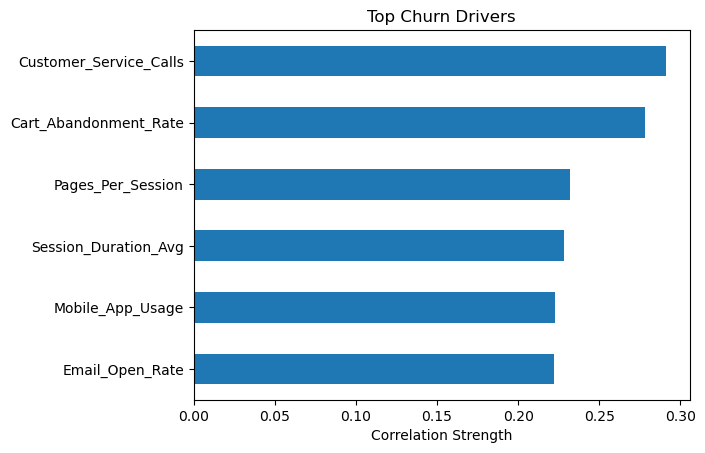

In [18]:
top_drivers.sort_values().plot(kind="barh")

plt.title("Top Churn Drivers")
plt.xlabel("Correlation Strength")

plt.show()

In [19]:
#Estimate Revenue at Risk
avg_ltv = df["Lifetime_Value"].mean()

churn_rate = df["Churned"].mean()

total_customers = len(df)

estimated_revenue_loss = avg_ltv * churn_rate * total_customers

print(f"Estimated Revenue at Risk: ${estimated_revenue_loss:,.2f}")

Estimated Revenue at Risk: $20,817,049.92


In [20]:
"""
Revenue Impact Insight

Based on the current churn rate and average customer lifetime value,
the platform risks losing approximately $20,817,049.92 in customer lifetime value.

Reducing churn by even 5% could recover a significant portion of this
lost revenue.
"""

'\nRevenue Impact Insight\n\nBased on the current churn rate and average customer lifetime value,\nthe platform risks losing approximately $20,817,049.92 in customer lifetime value.\n\nReducing churn by even 5% could recover a significant portion of this\nlost revenue.\n'

In [21]:
print("Average LTV:", avg_ltv)
print("Churn Rate:", churn_rate)
print("Total Customers:", total_customers)
print("Revenue at Risk:", estimated_revenue_loss)

Average LTV: 1440.6262920000001
Churn Rate: 0.289
Total Customers: 50000
Revenue at Risk: 20817049.9194


In [22]:
"""
Revenue Impact Analysis

The platform has an average customer lifetime value (LTV) of $1,440.
With a churn rate of 28.9% across 50,000 customers, approximately
14,450 customers are expected to churn.

This represents an estimated $20.8M in lifetime revenue at risk.

Even a modest 5% reduction in churn could recover over $1M in
customer lifetime value.
"""

'\nRevenue Impact Analysis\n\nThe platform has an average customer lifetime value (LTV) of $1,440.\nWith a churn rate of 28.9% across 50,000 customers, approximately\n14,450 customers are expected to churn.\n\nThis represents an estimated $20.8M in lifetime revenue at risk.\n\nEven a modest 5% reduction in churn could recover over $1M in\ncustomer lifetime value.\n'

In [23]:
#Impact of Reducing Churn
reduction = 0.05

recovered_revenue = avg_ltv * reduction * total_customers

print(f"Revenue recovered with 5% churn reduction: ${recovered_revenue:,.2f}")

Revenue recovered with 5% churn reduction: $3,601,565.73


In [26]:
#Segment-Level Revenue Risk
df.groupby("risk_segment",observed=True)[["Lifetime_Value","Churned"]].mean()

,Lifetime_Value,Churned
risk_segment,,
Low Risk,1829.995377,0.188830
Medium Risk,1305.895670,0.257797
High Risk,1279.319620,0.392135


In [29]:
"""
Segment-Level Revenue Risk

Customer segmentation reveals clear differences in both churn and lifetime value.

• Low Risk users show the highest lifetime value ($1,830) and lowest churn (18.9%).
• High Risk users churn at a significantly higher rate (39.2%) and generate lower lifetime value.

This suggests that improving engagement and purchase activity can both
increase revenue and reduce churn risk.

Targeting the High Risk segment with retention strategies represents the
highest leverage opportunity for reducing revenue loss.
"""

'\nSegment-Level Revenue Risk\n\nCustomer segmentation reveals clear differences in both churn and lifetime value.\n\n• Low Risk users show the highest lifetime value ($1,830) and lowest churn (18.9%).\n• High Risk users churn at a significantly higher rate (39.2%) and generate lower lifetime value.\n\nThis suggests that improving engagement and purchase activity can both\nincrease revenue and reduce churn risk.\n\nTargeting the High Risk segment with retention strategies represents the\nhighest leverage opportunity for reducing revenue loss.\n'

In [30]:
df.to_csv("../data/processed/customer_features.csv", index=False)